In [81]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

Phần 1 — Thống kê mô tả & đặc trưng

1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng
cột.

In [9]:
df = sns.load_dataset("iris") # load dữ liệu iris

print(df.head(5)) # Hiển thị 5 dòng đầu
print(df.shape) # (150,5) = (số dòng, số cột)
print(df.dtypes) # Kiểu dữ liệu từng cột

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và
IQR.

Nhận xét: Chỉ có 4 cột đầu tiên mới tính được vì cột cuối có dtype là object

In [46]:
first4_column = df.iloc[:,:4]
print("MEAN:")
print(first4_column.mean())
print()
print("MEDIAN:")
print(first4_column.median())
print()
print("MODE:")
print(first4_column.mode())
print()
print("VAR:")
print(first4_column.var())
print()
print("STD:")
print(first4_column.std())
print()
print("MIN:")
print(first4_column.min())
print()
print("MAX:")
print(first4_column.max())
print()
print("Q1:")
print(first4_column.quantile(0.25))
print()
print("Q3:")
print(first4_column.quantile(0.75))
print()
print("IQR:")
IQR = first4_column.quantile(0.75) - first4_column.quantile(0.25)
print(IQR)

MEAN:
sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

MEDIAN:
sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

MODE:
   sepal_length  sepal_width  petal_length  petal_width
0           5.0          3.0           1.4          0.2
1           NaN          NaN           1.5          NaN

VAR:
sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

STD:
sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

MIN:
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64

MAX:
sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64

Q1:
sepal_length    5.1
sepal_width     2.8
petal_length    1.6
petal_width     0.3
Name: 0.25, dtype: float64

Q3:
sepal_length    6.4
sepal_width    

3. Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến.
Nhận xét nhóm nào khác biệt rõ nhất.

Nhận xét: loài setosa khác biệt rõ nhất ở petal_length và petal_width

In [61]:
df_species = df.groupby('species')
df_species_mean = df_species.mean()

print("MEAN:")
print(df_species_mean)
print()

df_species_std = df_species.std()
print("STD:")
print(df_species_std)
        

MEAN:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026

STD:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


Phần 2 — Phân phối xác suất

1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch
trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?

Nhận xét:
    - Phân phối của sepal_length: lệnh trái, gần phân phối chuẩn
    - Phân phối của sepal_width: lệnh trái, gần phân phối chuẩn
    - Phân phối của petal_length: lệnh phải, nhiều đỉnh
    - Phân phối của petal_width: lệnh phải, nhiều đỉnh


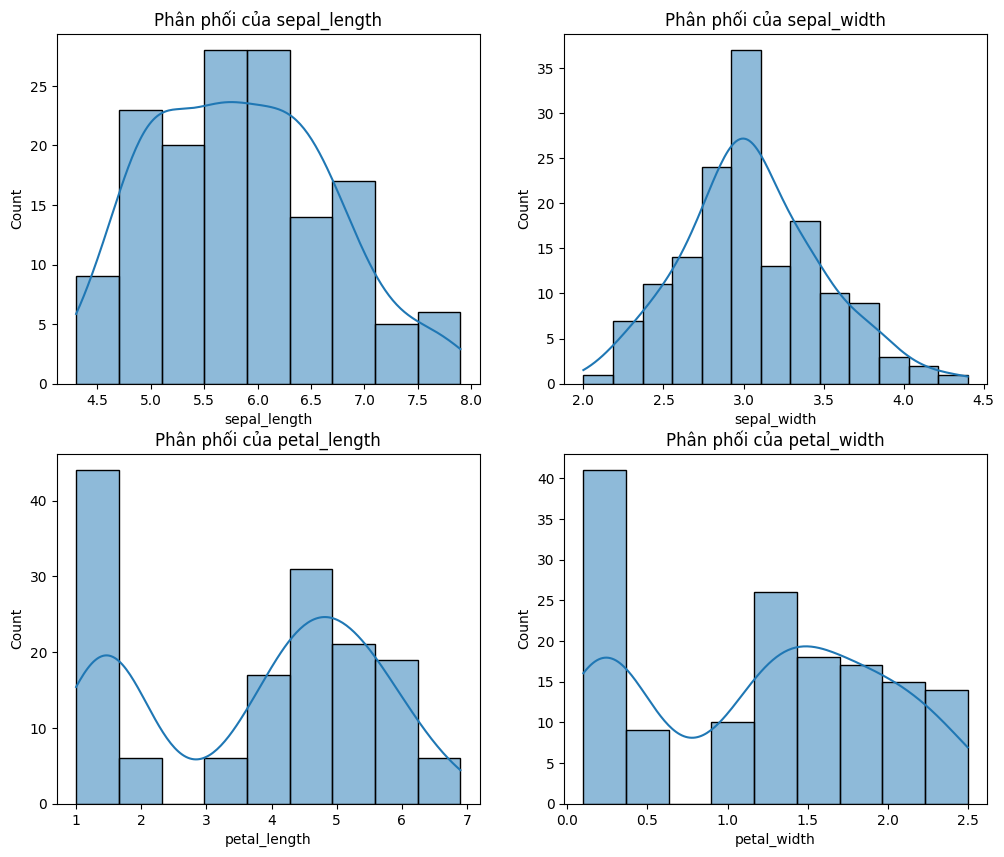

In [67]:
numeric_cols = df.select_dtypes(include=['float64']).columns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Phân phối của {col}')

plt.show()

2. Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài.

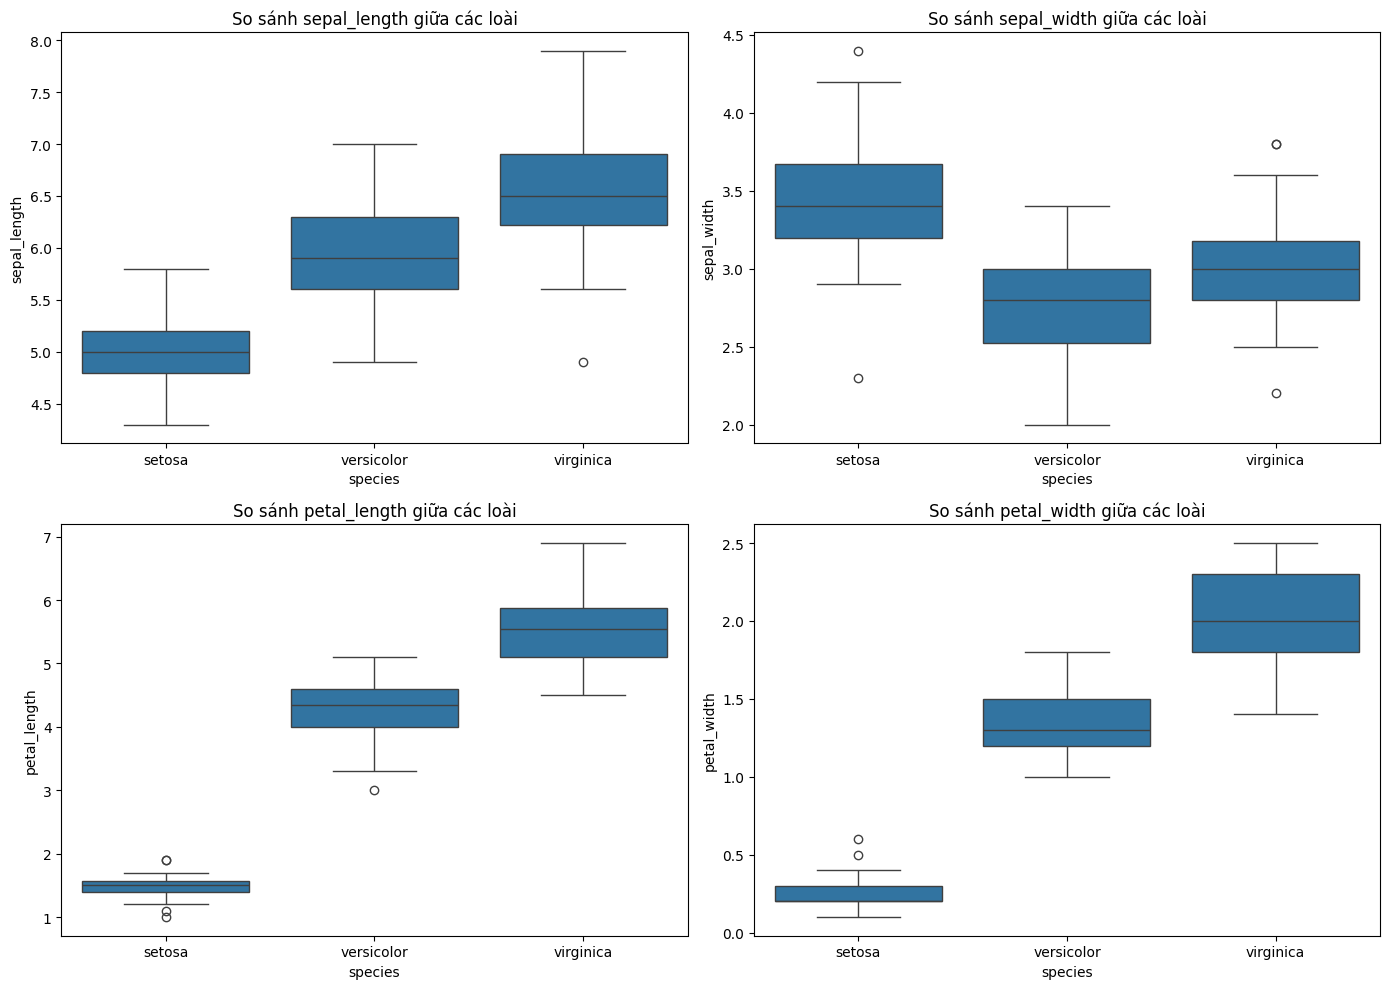

In [69]:
numeric_cols = df.select_dtypes(include=['float64']).columns

# Thiết lập layout cho 4 biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i])
    axes[i].set_title(f'So sánh {col} giữa các loài')

plt.tight_layout()
plt.show()

3. Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và
std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý
thuyết. Nhận xét mức độ khớp.

Biến em chọn: Sepal_length
Mức độ khớp: Không khớp hoàn hảo nhưng vẫn giống vài phần.

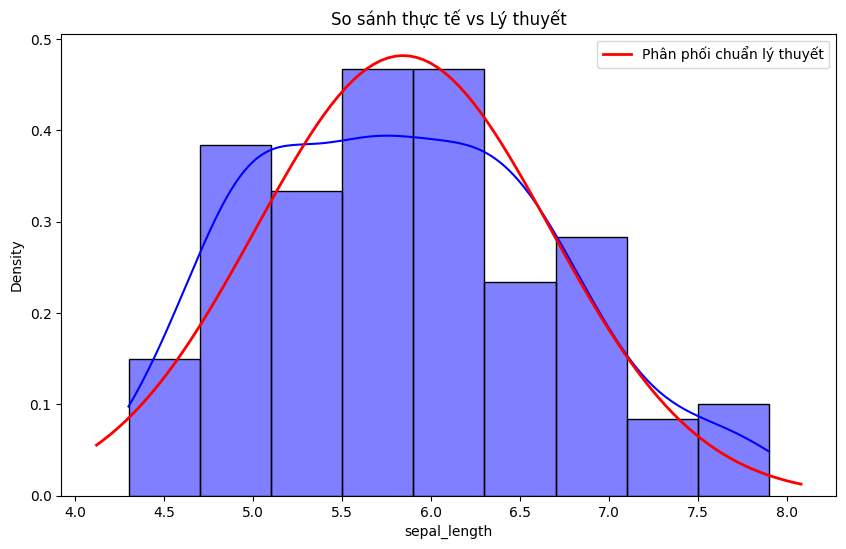

In [95]:
df_sepal_length = df['sepal_length']
mean = df_sepal_length.mean()
std = df_sepal_length.std()
sample = np.random.normal(mean,std,size = len(df_sepal_length))

plt.figure(figsize=(10, 6))
sns.histplot(df_sepal_length, color='blue',kde=True, stat='density')

# Đường PDF lý thuyết
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std)
plt.plot(x, p, 'r', linewidth=2, label='Phân phối chuẩn lý thuyết')

plt.title(f'So sánh thực tế vs Lý thuyết')
plt.legend()
plt.show()


Phần 3 — Phân tích đa biến & tương quan

1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa
các biến số.

In [110]:
print("ma trận hiệp phương sai:")
cov_matrix = df.select_dtypes(include=['float64']).cov()
print(cov_matrix)
print()
print("ma trận tương quan:")
corr_matrix = df.select_dtypes(include=['float64']).corr()
print(corr_matrix)

ma trận hiệp phương sai:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

ma trận tương quan:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


2. Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu
đa cộng tuyến không?

Có, vì corr(petal_length, petal_width) = 0.96; corr(petal_length, sepal_length) = 0.87; corr(petal_width, sepal_length) = 0.82.

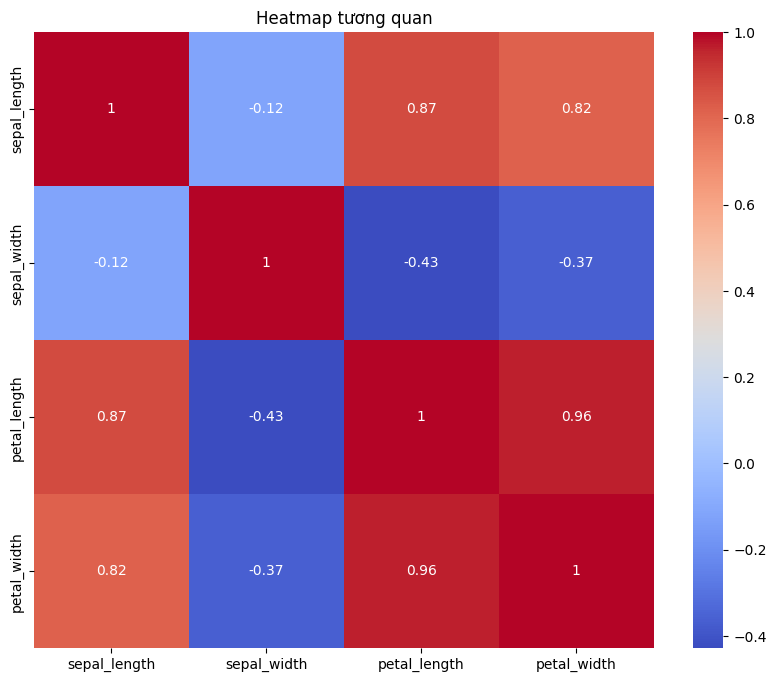

In [115]:
corr_matrix = df.select_dtypes(include=['float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap tương quan')
plt.show()

3. Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa
các biến.

Nhận xét: loài setosa có dữ liệu tách biệt so với 2 loài còn lại; 2 loài versicolor và virginica thì chồng lấp nhau.

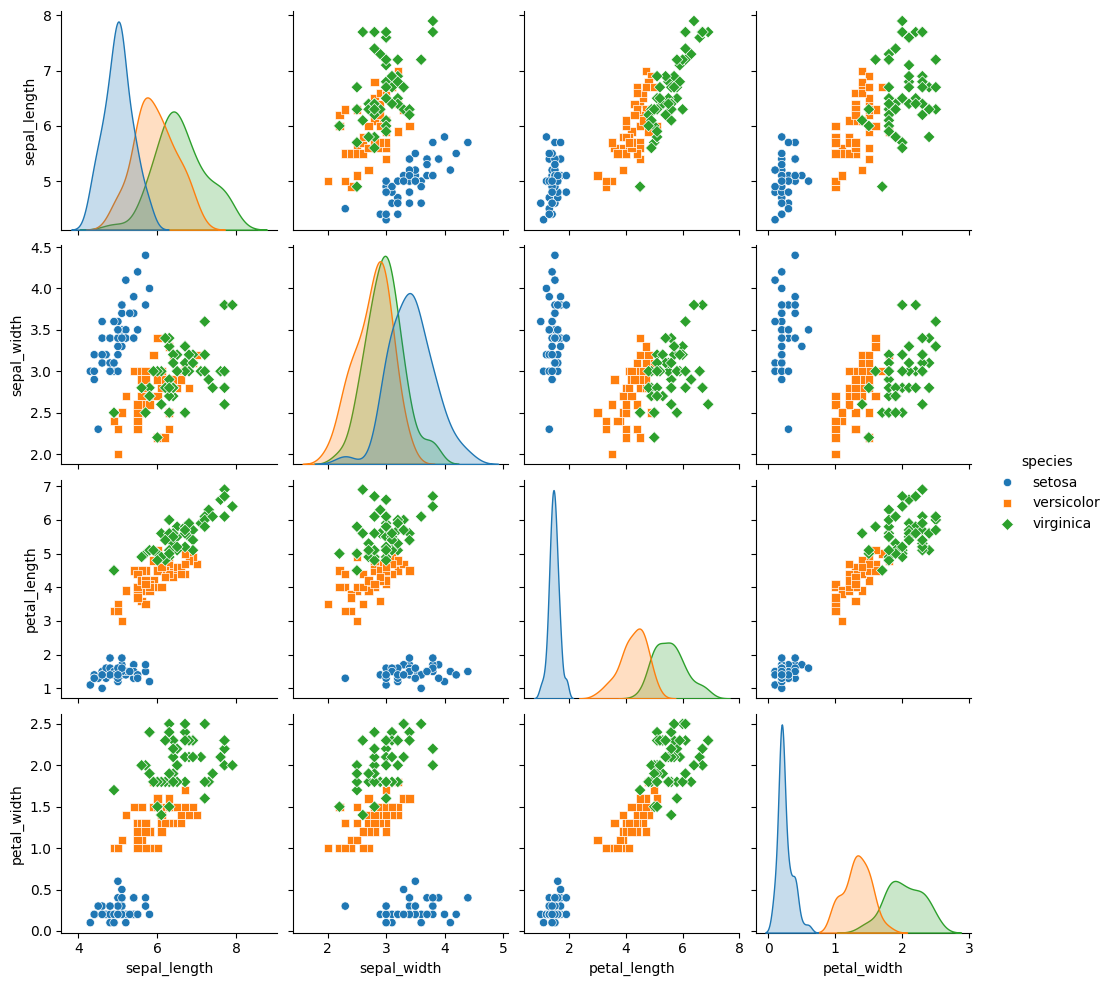

In [116]:
sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.show()

Phần 4 — Xác suất & Định lý Bayes

1. Viết code tính xác suất hậu nghiệm P (B |+) bằng định lý Bayes và in kết qu

In [118]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05

P_B_given_pos = (P_pos_givenB*P_B)/(P_pos_givenB*P_B + P_pos_givenNB*(1-P_B))
round(P_B_given_pos,4)

0.1667

2. Khảo sát: vẽ đồ thị P (B |+) khi tỉ lệ mắc bệnh P (B) thay đổi từ 0.001 đến 0.2.
Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".

Giải thích: Khi bệnh hiếm thì xác suất P(B|+) sẽ giảm nên dù độ nhạy cao khoảng 0.99 thì vẫn chưa chắc bệnh nhân thực sự mắc bệnh.

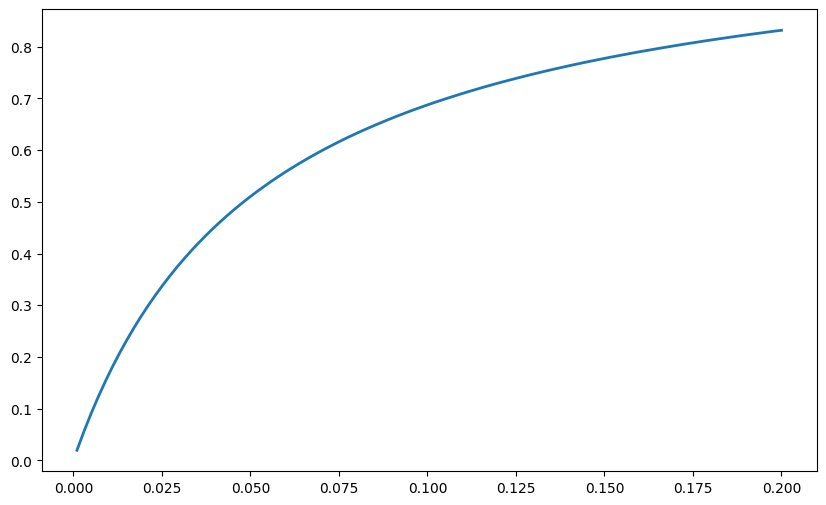

In [120]:
def calculate(P_B, P_pos_givenB = 0.99, P_pos_givenNB = 0.05):
    P_B_given_pos = (P_pos_givenB*P_B)/(P_pos_givenB*P_B + P_pos_givenNB*(1-P_B))
    return round(P_B_given_pos,4)

intervals = np.linspace(0.001, 0.2, 100)
posteriors = [calculate(p) for p in intervals]

plt.figure(figsize=(10, 6))
plt.plot(intervals, posteriors, label='P(B|+)', linewidth=2)
plt.show()